# scarlatti-doodle

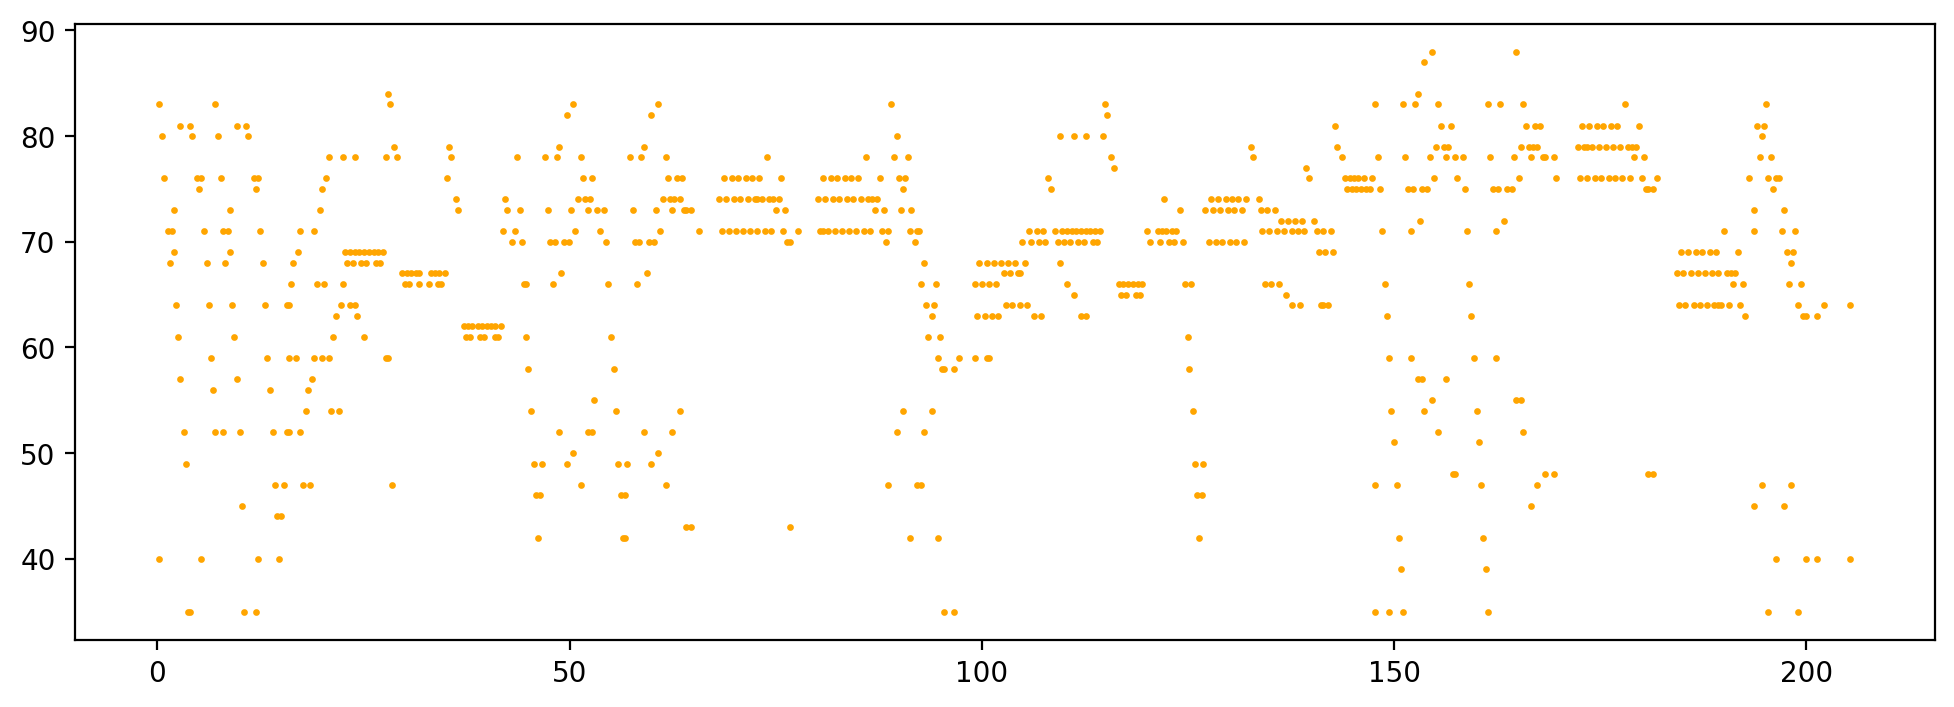

PosixPath('/tmp/tmpadfhoqiw.musicxml')

In [6]:
from music21 import converter

score = converter.parse("sonatas_k-531_(c)sankey.mid")

import matplotlib.pyplot as plt
import numpy as np # 숫자 변환을 도와주는 도구

# 1. 데이터를 뽑을 때 아예 실수(float)로 강제 변환합니다.
raw_pitches = [float(n.pitch.ps) for n in score.flatten().notes if getattr(n, 'isNote', False) and not n.isChord]
raw_offsets = [float(n.offset) for n in score.flatten().notes if getattr(n, 'isNote', False) and not n.isChord]

# 2. 혹시나 섞여 있을지 모르는 '이상한 값'들을 넘파이(numpy)로 한 번 더 걸러냅니다.
pitches = np.array(raw_pitches, dtype=float)
offsets = np.array(raw_offsets, dtype=float)

# 3. 그리기
plt.figure(figsize=(12, 4))
plt.scatter(offsets, pitches, s=2, c='orange')
plt.show()

score.write()


## Google Drive 마운트
#### written using AI

In [ ]:
import io
import os
import zipfile
from music21 import converter, midi, environment

# music21 경로 억까 방지 환경 설정
try:
    environment.Environment()['directoryScratch'] = '/tmp'
except:
    pass

def mount_scarlatti():
    """scarlatti.zip을 가상 메모리에 마운트하고, 
    파일을 언제든 꺼내 쓸 수 있는 가상 폴더 객체(ZipFile)와 파일 명단을 반환합니다."""
    ZIP_FILE_PATH = "original_midi.zip"
    
    if not os.path.exists(ZIP_FILE_PATH):
        raise FileNotFoundError(f"⚠️ '{ZIP_FILE_PATH}' 파일이 없습니다. 왼쪽 탐색기에 업로드해 주세요!")
        
    print("🛸 가상 메모리(RAM)에 스칼라티 555개 소나타 마운트 중...")
    
    # 파일을 RAM으로 읽어오기
    with open(ZIP_FILE_PATH, "rb") as f:
        zip_buffer = io.BytesIO(f.read())
        
    # Zip 아카이브 객체 생성
    archive = zipfile.ZipFile(zip_buffer)
    
    # 미디 파일 목록만 싹 긁어오기
    midi_files = [f for f in archive.namelist() if f.lower().endswith(('.mid', '.midi'))]
    print(f"📦 마운트 완료! 총 {len(midi_files)}개의 가상 미디 폴더 준비 완료.")
    
    return archive, midi_files

def load_midi_from_virtual_folder(archive, file_path):
    """가상 폴더(archive)와 파일 경로를 주면, 디스크 IO 없이 music21 Score 객체로 즉시 변환합니다."""
    midi_raw_bytes = archive.read(file_path)
    
    # 샌드박스 바이트 스트림 파싱 (우리가 방금 성공한 그 정석 코드)
    mf = midi.MidiFile()
    mf.readstr(midi_raw_bytes)
    return midi.translate.midiFileToStream(mf)

# 🔥 [실행] 가상 폴더 연결하기
# 앞으로 코드 짤 때는 이 두 변수(scarlatti_folder, file_list)만 가지고 노시면 됩니다!
scarlatti_folder, file_list = mount_scarlatti()
print("앞으로 scarlatti_folder, file_list에 접근해서 사용! load_midi_from_virtual_folder 함수 사용")

# 미디 시각화하는 함수 작성
from music21 import converter
import matplotlib.pyplot as plt
import numpy as np # 숫자 변환을 도와주는 도구

def ShowMidi(score):
    # 1. 데이터를 뽑을 때 아예 실수(float)로 강제 변환합니다.
    raw_pitches = [float(n.pitch.ps) for n in score.flatten().notes if getattr(n, 'isNote', False) and not n.isChord]
    raw_offsets = [float(n.offset) for n in score.flatten().notes if getattr(n, 'isNote', False) and not n.isChord]

    # 2. 혹시나 섞여 있을지 모르는 '이상한 값'들을 넘파이(numpy)로 한 번 더 걸러냅니다.
    pitches = np.array(raw_pitches, dtype=float)
    offsets = np.array(raw_offsets, dtype=float)

    # 3. 그리기
    plt.figure(figsize=(12, 4))
    plt.scatter(offsets, pitches, s=2, c='orange')
    plt.show()

    score.write()

print("ShowMidi 함수 준비됨!")

🛸 가상 메모리(RAM)에 스칼라티 555개 소나타 마운트 중...
📦 마운트 완료! 총 555개의 가상 미디 폴더 준비 완료.
앞으로 scarlatti_folder, file_list에 접근해서 사용!
ShowMidi 함수 준비됨!


### 555개 소나타 접근해서 장조 단조 비율 확인하기

In [26]:
import matplotlib.pyplot as plt

major_count = 0
minor_count = 0

for filename in file_list:
    tonality = load_midi_from_virtual_folder(scarlatti_folder, filename).analyze('key').mode
    if tonality == "major":
        major_count += 1
    else:
        minor_count += 1

print(major_count)
print(minor_count)
    


376
179


<function matplotlib.pyplot.show(close=None, block=None)>

/home/codespace/.local/lib/python3.12/site-packages/IPython/core/events.py:100: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/codespace/.local/lib/python3.12/site-packages/IPython/core/events.py:100: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/codespace/.local/lib/python3.12/site-packages/IPython/core/events.py:100: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/codespace/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/codespace/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/codes

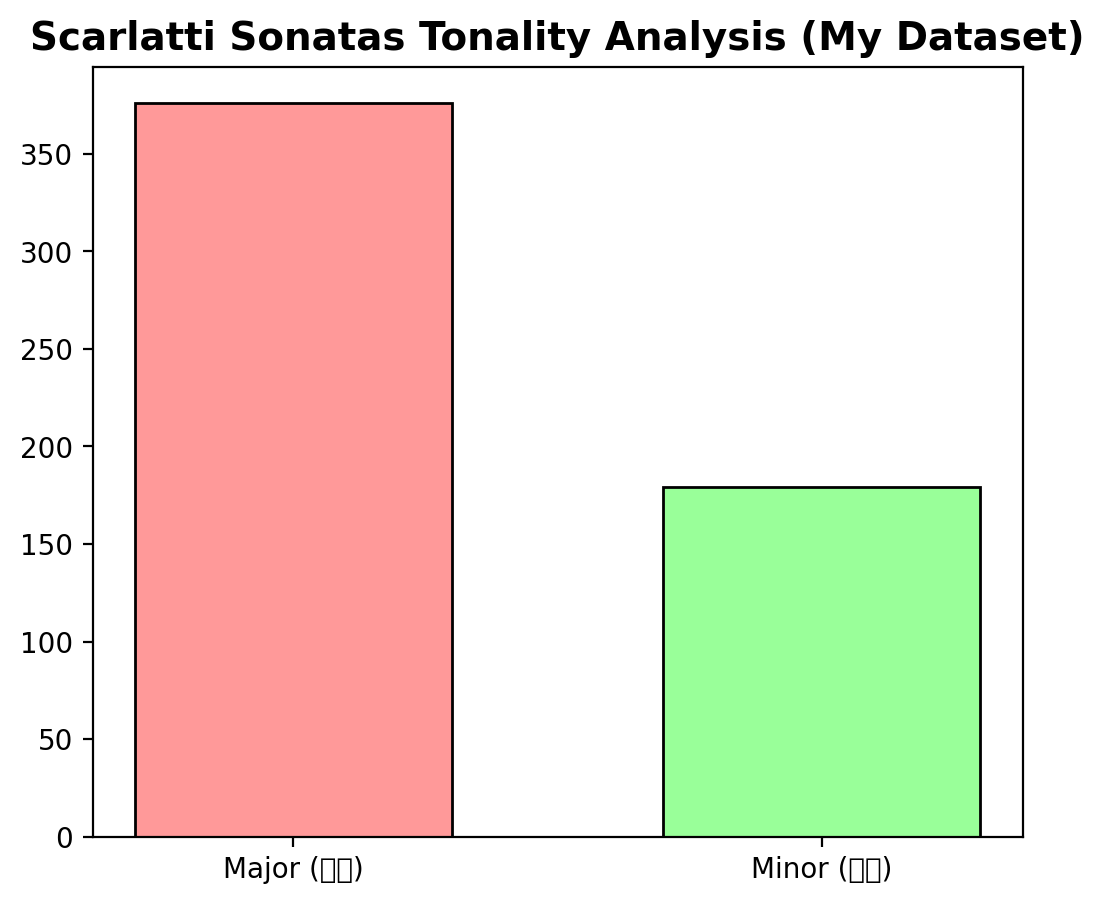

In [27]:
# 분석한 데이터 세팅
categories = ['Major (장조)', 'Minor (단조)']
counts = [major_count, minor_count]
colors = ['#ff9999', '#99ff99'] # 파스텔톤 핑크, 연두

# 그래프 그리기
plt.figure(figsize=(6, 5))
plt.bar(categories, counts, color=colors, edgecolor='black', width=0.6)

# 그래프 제목 및 축 설정
plt.title("Scarlatti Sonatas Tonality Analysis (My Dataset)", fontsize=14, fontweight='bold')
plt.show

#### midi 파일로 기능 사전 테스트

original/sonatas_k-537_(c)sankey.mid
1
{0.0} <music21.stream.Measure 1 offset=0.0>
    {0.0} <music21.instrument.Harpsichord 'Harpsichord'>
    {0.0} <music21.clef.TrebleClef>
    {0.0} <music21.tempo.MetronomeMark animato Quarter=120>
    {0.0} <music21.meter.TimeSignature 4/4>
    {0.0} <music21.stream.Voice 0x7e6e0b1876e0>
        {0.0} <music21.note.Rest 16th>
        {0.25} <music21.note.Note A>
        {1.0} <music21.note.Rest 1/3ql>
        {1.3333} <music21.note.Note F#>
        {1.8333} <music21.note.Rest eighth>
        {2.3333} <music21.note.Note B>
        {2.8333} <music21.note.Rest eighth>
        {3.3333} <music21.note.Note E>
    {0.0} <music21.stream.Voice 0x7e6e08044680>
        {0.0} <music21.note.Rest dotted-eighth>
        {0.75} <music21.note.Note A>
        {1.4167} <music21.note.Rest 1/3ql>
        {1.75} <music21.note.Note D>
        {2.4167} <music21.note.Rest 1/3ql>
        {2.75} <music21.note.Note G#>
        {3.4167} <music21.note.Rest 7/12ql>
{4.0} <music

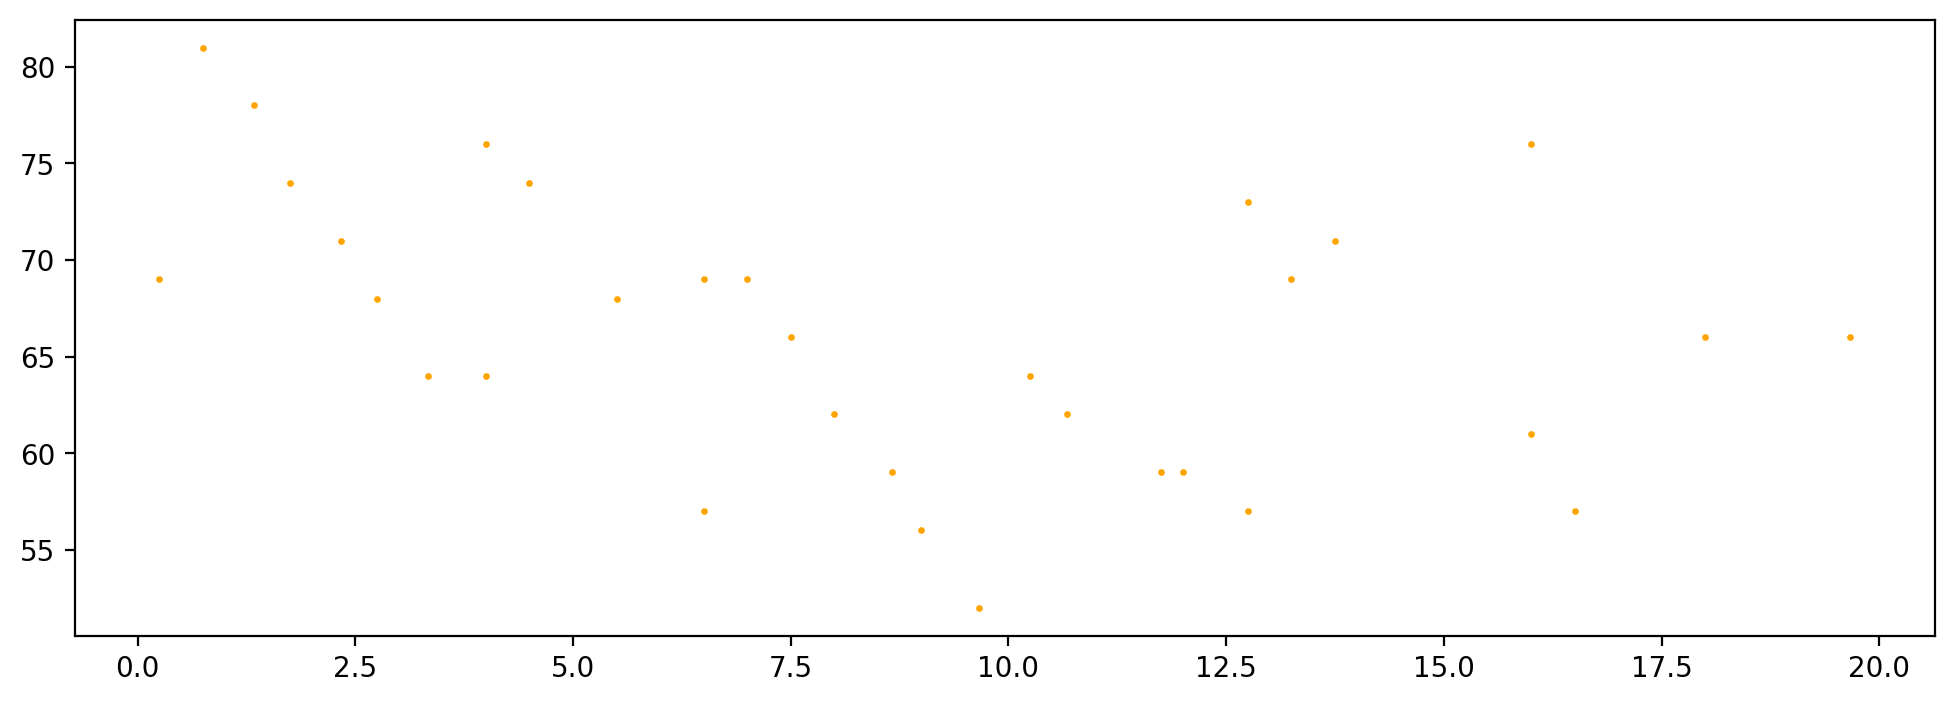

🎹 이 곡에서 두 음 이상 동시에 연주되는 지점은 총 38곳 입니다!
 - [1번째 동시연주] 시간: 0.75박자 위치 / 구성음: ['A4', 'A5']
 - [2번째 동시연주] 시간: 4/3박자 위치 / 구성음: ['F#5', 'A5']
 - [3번째 동시연주] 시간: 1.75박자 위치 / 구성음: ['D5', 'F#5']
 - [4번째 동시연주] 시간: 7/3박자 위치 / 구성음: ['B4', 'D5']
 - [5번째 동시연주] 시간: 2.75박자 위치 / 구성음: ['G#4', 'B4']


In [ ]:
import music21

score = load_midi_from_virtual_folder(scarlatti_folder, file_list[5])
print(file_list[5])

part = score.parts[0]
print(len(score.parts))
measures_1_to_4 = part.measures(1, 5)

# 분리된 마디 데이터 확인
measures_1_to_4.show('text')

# 분리된 악보 화면으로 띄우기
ShowMidi(measures_1_to_4)




# .chordify()는 모든 성부의 음표들을 시간대별로 쾅! 눌러서 
# 동시 연주되는 애들을 '화음(Chord)' 객체로 묶어주는 대박 함수야.
chordified_score = measures_1_to_4.chordify()

# 그중에서 음이 2개 이상 동시에 연주되는 진짜 화음만 골라내기
multi_note_chords = [c for c in chordified_score.recurse().getElementsByClass('Chord') if len(c.pitches) >= 2]

print(f"🎹 이 곡에서 두 음 이상 동시에 연주되는 지점은 총 {len(multi_note_chords)}곳 입니다!")

# 그중 앞의 5개 지점은 어떤 음들이 동시에 눌렸는지 구경해보기
for i, c in enumerate(multi_note_chords[:5]):
    print(f" - [{i+1}번째 동시연주] 시간: {c.offset}박자 위치 / 구성음: {[p.nameWithOctave for p in c.pitches]}")